In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.impute import KNNImputer

df1 = pd.read_excel("C:\\Users\\arunp\\Downloads\\Forecasting data\\Boys.xlsb")
df2 = pd.read_excel("C:\\Users\\arunp\\Downloads\\Additional data\\Additional data\\boys data - additional months.xlsb")
df = pd.concat([df1, df2])

In [2]:
df['Posting Date'] = pd.to_datetime('1899-12-30') + pd.to_timedelta(df['Posting Date'], unit='D')

In [3]:
required_columns = ['Posting Date','Net Sale Value','Qty','Size','Sleeve','Length','Range','Department']
df = df[required_columns]

In [4]:
df['Department'] = df['Department'].astype(str).str.upper().str.strip()
df = df[df['Department'].isin(['KNIT TOP SETS','WOVEN TOP SETS'])]

In [5]:
length_mask = df['Length'].notna()
df.loc[length_mask, 'Length'] = df.loc[length_mask, 'Length'].astype(str).str.strip().str.upper()
df.loc[length_mask, 'Length'] = df.loc[length_mask, 'Length'].replace({
    'FULL LENGTH': 'Full Length',
    'REGULAR': 'Half Length',
    'SHORT': 'Half Length',
    'CALF LENGTH (3/4TH)': 'Half Length',
    'ABOVE KNEE (1/2)': 'Half Length',
    'MINI': 'Half Length',
    'KNEE LENGTH': 'Half Length',
    'CROP': 'Half Length'
})

In [6]:
sleeve_mask = df['Sleeve'].notna()
df.loc[sleeve_mask, 'Sleeve'] = df.loc[sleeve_mask, 'Sleeve'].astype(str).str.strip().str.upper()
df.loc[sleeve_mask, 'Sleeve'] = df.loc[sleeve_mask, 'Sleeve'].replace({
    'FULL SLEEVE': 'Full Sleeve',
    'SHORT SLEEVE': 'Short Sleeve',
    'SLEEVE LESS': 'Short Sleeve'
})

In [7]:
df = df.groupby([
    'Posting Date','Size','Sleeve','Length','Range','Department'
])[['Qty','Net Sale Value']].sum().reset_index()

In [8]:
from sklearn.preprocessing import LabelEncoder
encoders = {}
for col in ['Length','Sleeve']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

imputer = KNNImputer(n_neighbors=5)
df[['Length','Sleeve']] = imputer.fit_transform(df[['Length','Sleeve']])

for col in ['Length','Sleeve']:
    df[col] = encoders[col].inverse_transform(df[col].astype(int))

In [9]:
events = [
    {"Event":"Women's Day","From":"2024-03-08","To":"2024-03-10"},
    {"Event":"Anniversary Sale","From":"2024-09-04","To":"2024-09-16"},
    {"Event":"Diwali","From":"2024-10-08","To":"2024-10-31"},
    {"Event":"Women's Day","From":"2025-03-07","To":"2025-03-09"},
    {"Event":"Anniversary Sale","From":"2025-08-26","To":"2025-09-07"},
    {"Event":"Diwali","From":"2025-09-27","To":"2025-10-20"}
]

df['Event'] = 'None'
for e in events:
    mask = (df['Posting Date']>=pd.to_datetime(e['From'])) & (df['Posting Date']<=pd.to_datetime(e['To']))
    df.loc[mask,'Event'] = e['Event']

In [10]:
prophet_df = df[['Posting Date','Net Sale Value']].rename(columns={'Posting Date':'ds','Net Sale Value':'y'})
prophet_df['event'] = (df['Event']!='None').astype(int)

In [11]:
split_date = prophet_df['ds'].max() - pd.Timedelta(days=30)
train = prophet_df[prophet_df['ds'] <= split_date]
test = prophet_df[prophet_df['ds'] > split_date]

In [12]:
m = Prophet(weekly_seasonality=True, yearly_seasonality=True)
m.add_regressor('event')
m.fit(train)

09:17:27 - cmdstanpy - INFO - Chain [1] start processing
09:17:30 - cmdstanpy - INFO - Chain [1] done processing


In [13]:
def weighted_ape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100
forecast_test = m.predict(test[['ds','event']])
wape = weighted_ape(test['y'].values, forecast_test['yhat'].values)
print("Weighted APE (Sales Amount):", round(wape,2))

Weighted APE (Sales Amount): 101.63


In [14]:
df['WeekOfYear'] = df['Posting Date'].dt.isocalendar().week.astype(int)
df['Month'] = df['Posting Date'].dt.month
df['Year'] = df['Posting Date'].dt.year

weekly_sales = df.groupby(['Year','WeekOfYear','Size','Sleeve','Length','Range'])[['Qty','Net Sale Value']].sum().reset_index()
monthly_sales = df.groupby(['Year','Month','Size','Sleeve','Length','Range'])[['Qty','Net Sale Value']].sum().reset_index()
yearly_sales = df.groupby(['Year','Size','Sleeve','Length','Range'])[['Qty','Net Sale Value']].sum().reset_index()

In [21]:
highest_week = weekly_sales.loc[weekly_sales['Net Sale Value'].idxmax()]
lowest_week = weekly_sales.loc[weekly_sales['Net Sale Value'].idxmin()]

highest_month = monthly_sales.loc[monthly_sales['Net Sale Value'].idxmax()]
lowest_month = monthly_sales.loc[monthly_sales['Net Sale Value'].idxmin()]

highest_year = yearly_sales.loc[yearly_sales['Net Sale Value'].idxmax()]
lowest_year = yearly_sales.loc[yearly_sales['Net Sale Value'].idxmin()]
print("Highest Week:", highest_week)


Highest Week: Year                     2025
WeekOfYear                 42
Size                 4/3XL/22
Sleeve            Full Sleeve
Length            Full Length
Range               1201-1650
Qty                        45
Net Sale Value       59113.96
Name: 6315, dtype: object


In [22]:
print("Lowest Week:", lowest_week)

Lowest Week: Year                     2025
WeekOfYear                 44
Size                     7/27
Sleeve            Full Sleeve
Length            Full Length
Range               2201-3400
Qty                        -2
Net Sale Value        -4437.9
Name: 6475, dtype: object


In [23]:
print("Highest Month:", highest_month)


Highest Month: Year                      2024
Month                       10
Size                    1/L/16
Sleeve            Short Sleeve
Length             Half Length
Range                 701-1050
Qty                        189
Net Sale Value       163183.88
Name: 781, dtype: object


In [24]:

print("Lowest Month:", lowest_month)


Lowest Month: Year                     2024
Month                      11
Size                    10/30
Sleeve            Full Sleeve
Length            Full Length
Range               1651-2200
Qty                        -1
Net Sale Value        -1665.0
Name: 892, dtype: object


In [25]:
print("Highest Year:", highest_year)


Highest Year: Year                      2025
Size                    0/M/14
Sleeve            Short Sleeve
Length             Half Length
Range                 701-1050
Qty                        967
Net Sale Value        785580.2
Name: 161, dtype: object


In [26]:
print("Lowest Year:", lowest_year)

Lowest Year: Year                      2024
Size                    0/M/14
Sleeve            Short Sleeve
Length             Full Length
Range                1651-2200
Qty                          1
Net Sale Value           186.5
Name: 8, dtype: object


In [27]:
def get_sales(period="week", number=1, size_filter="M", length="Full Length", sleeve="Short Sleeve", range_val="200-400"):
    """
    period: 'week', 'month', or 'year'
    number: week number, month number, or year value
    size_filter: substring to match in Size column
    length, sleeve, range_val: exact matches
    """
    if period == "week":
        subset = weekly_sales[
            (weekly_sales['WeekOfYear']==number) &
            (weekly_sales['Size'].str.contains(size_filter, case=False, na=False)) &
            (weekly_sales['Length']==length) &
            (weekly_sales['Sleeve'].str.upper().str.contains(sleeve.upper(), na=False)) &
            (weekly_sales['Range']==range_val)
        ]
        if subset.empty:
            print(f"Product not sold in Week {number}.")
        else:
            print(f"Sales in Week {number}:")
            print(subset)

    elif period == "month":
        subset = monthly_sales[
            (monthly_sales['Month']==number) &
            (monthly_sales['Size'].str.contains(size_filter, case=False, na=False)) &
            (monthly_sales['Length']==length) &
            (monthly_sales['Sleeve'].str.upper().str.contains(sleeve.upper(), na=False)) &
            (monthly_sales['Range']==range_val)
        ]
        if subset.empty:
            print(f"Product not sold in Month {number}.")
        else:
            print(f"Sales in Month {number}:")
            print(subset)

    elif period == "year":
        subset = yearly_sales[
            (yearly_sales['Year']==number) &
            (yearly_sales['Size'].str.contains(size_filter, case=False, na=False)) &
            (yearly_sales['Length']==length) &
            (yearly_sales['Sleeve'].str.upper().str.contains(sleeve.upper(), na=False)) &
            (yearly_sales['Range']==range_val)
        ]
        if subset.empty:
            print(f"Product not sold in Year {number}.")
        else:
            print(f"Sales in Year {number}:")
            print(subset)


get_sales(period="week", number=2, size_filter="0/M/14", length="Full Length", sleeve="FULL SLEEVE", range_val="600-1200")


Sales in Week 2:
      Year  WeekOfYear    Size       Sleeve       Length     Range  Qty  \
3423  2025           2  0/M/14  Full Sleeve  Full Length  600-1200   14   

      Net Sale Value  
3423         9524.01  


In [28]:
get_sales(period="month", number=34, size_filter="0/M/14", length="Full Length", sleeve="FULL SLEEVE", range_val="600-1200")


Product not sold in Month 34.


In [29]:
get_sales(period="year", number=2025, size_filter="0/M/14", length="Full Length", sleeve="FULL SLEEVE", range_val="600-1200")

Sales in Year 2025:
     Year    Size       Sleeve       Length     Range  Qty  Net Sale Value
152  2025  0/M/14  Full Sleeve  Full Length  600-1200  159       136665.58


In [30]:
event_sales = df[df['Event']!='None'].groupby(['Event','Year','Month','WeekOfYear'])[['Qty','Net Sale Value']].sum().reset_index()
print("Event Sales:\n", event_sales)

Event Sales:
                Event  Year  Month  WeekOfYear   Qty  Net Sale Value
0   Anniversary Sale  2024      9          36  1661       799241.10
1   Anniversary Sale  2024      9          37  1387       712232.47
2   Anniversary Sale  2024      9          38   209        94243.89
3   Anniversary Sale  2025      8          35  1681       820793.14
4   Anniversary Sale  2025      9          36  1318       664314.65
5             Diwali  2024     10          41   616       575796.98
6             Diwali  2024     10          42   730       685647.09
7             Diwali  2024     10          43  1035       977986.84
8             Diwali  2024     10          44   580       523372.14
9             Diwali  2025      9          39   213       175836.50
10            Diwali  2025      9          40   139       131594.06
11            Diwali  2025     10          40  1286      1129690.56
12            Diwali  2025     10          41   973       823293.62
13            Diwali  2025     10 

In [31]:
future = m.make_future_dataframe(periods=365*20)
future['event'] = 0
for e in events:
    for yr in [2026, 2027, 2028, 2030, 2045]:
        start = pd.to_datetime(e["From"]).replace(year=yr)
        end = pd.to_datetime(e["To"]).replace(year=yr)
        future.loc[(future['ds']>=start) & (future['ds']<=end), 'event'] = 1

forecast = m.predict(future)  
future_event_sales = pd.DataFrame([
    {
        "Event": e["Event"],
        "Year": yr,
        "Month": pd.to_datetime(e["From"]).month,
        "WeekOfYear": pd.to_datetime(e["From"]).isocalendar().week,
        "Predicted Net Sale Value": round(
            forecast.loc[
                (forecast['ds']>=pd.to_datetime(e["From"]).replace(year=yr)) &
                (forecast['ds']<=pd.to_datetime(e["To"]).replace(year=yr)),
                'yhat'
            ].sum(), 2
        )
    }
    for e in events for yr in [2026, 2027, 2028, 2030, 2045]
])

print("Future Event Sales:\n", future_event_sales)


Future Event Sales:
                Event  Year  Month  WeekOfYear  Predicted Net Sale Value
0        Women's Day  2026      3          10                   9965.55
1        Women's Day  2027      3          10                  15727.04
2        Women's Day  2028      3          10                  21897.01
3        Women's Day  2030      3          10                  34715.04
4        Women's Day  2045      3          10                 125192.35
5   Anniversary Sale  2026      9          36                  50700.21
6   Anniversary Sale  2027      9          36                  76985.89
7   Anniversary Sale  2028      9          36                 103103.42
8   Anniversary Sale  2030      9          36                 156108.04
9   Anniversary Sale  2045      9          36                 550652.43
10            Diwali  2026     10          41                 115813.65
11            Diwali  2027     10          41                 164733.48
12            Diwali  2028     10          

In [32]:
future_7d = forecast[forecast['ds'] <= forecast['ds'].min()+pd.Timedelta(days=7)]
future_1m = forecast[forecast['ds'] <= forecast['ds'].min()+pd.Timedelta(days=30)]
future_3m = forecast[forecast['ds'] <= forecast['ds'].min()+pd.Timedelta(days=90)]
future_1y = forecast[forecast['ds'] <= forecast['ds'].min()+pd.Timedelta(days=365)]

#print("Future 7 Days Forecast:\n", future_7d[['ds','yhat','yhat_lower','yhat_upper']])
#print("Future 1 Month Forecast:\n", future_1m[['ds','yhat','yhat_lower','yhat_upper']])
#print("Future 3 Months Forecast:\n", future_3m[['ds','yhat','yhat_lower','yhat_upper']])
#print("Future 1 Year Forecast:\n", future_1y[['ds','yhat','yhat_lower','yhat_upper']])"""

In [33]:
print("Total Future 7 Days Sales:", future_7d['yhat'].sum())
print("Total Future 1 Month Sales:", future_1m['yhat'].sum())
print("Total Future 3 Months Sales:", future_3m['yhat'].sum())
print("Total Future 1 Year Sales:", future_1y['yhat'].sum())

Total Future 7 Days Sales: 8331.927972188685
Total Future 1 Month Sales: 34952.46307737847
Total Future 3 Months Sales: 109518.26290588098
Total Future 1 Year Sales: 474511.947403866


In [34]:
forecast_df = forecast[['ds','yhat']].rename(columns={'ds':'Posting Date','yhat':'Predicted_Net_Sale'})
merged = pd.merge(df[['Posting Date','Net Sale Value']], forecast_df, on='Posting Date', how='inner')

weekly_pred = merged.groupby(merged['Posting Date'].dt.isocalendar().week)[['Net Sale Value','Predicted_Net_Sale']].sum().reset_index()
monthly_pred = merged.groupby(merged['Posting Date'].dt.month)[['Net Sale Value','Predicted_Net_Sale']].sum().reset_index()
yearly_pred = merged.groupby(merged['Posting Date'].dt.year)[['Net Sale Value','Predicted_Net_Sale']].sum().reset_index()

print("Weekly WAPE:", round(weighted_ape(weekly_pred['Net Sale Value'], weekly_pred['Predicted_Net_Sale']),2))
print("Monthly WAPE:", round(weighted_ape(monthly_pred['Net Sale Value'], monthly_pred['Predicted_Net_Sale']),2))
print("Yearly WAPE:", round(weighted_ape(yearly_pred['Net Sale Value'], yearly_pred['Predicted_Net_Sale']),2))

Weekly WAPE: 11.17
Monthly WAPE: 9.45
Yearly WAPE: 5.59


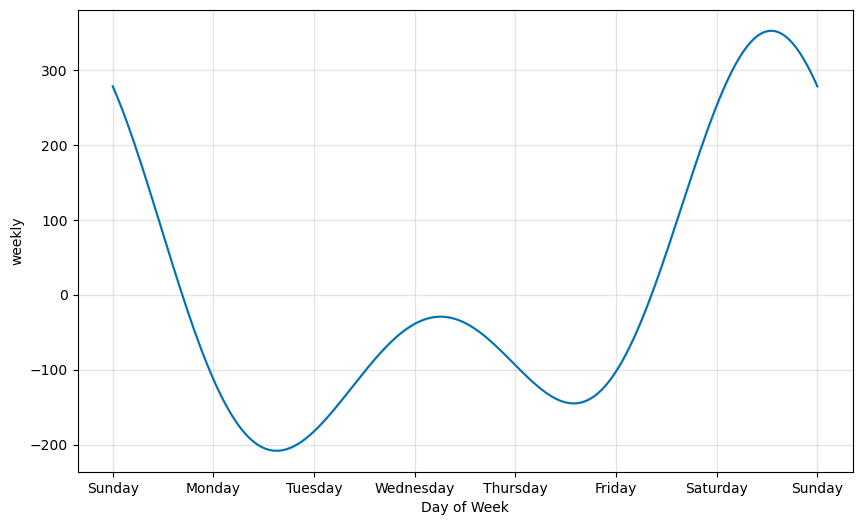

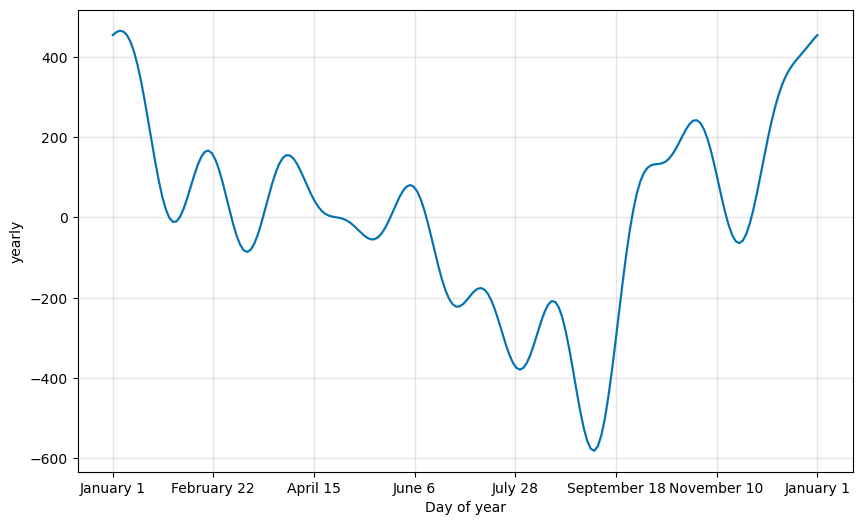

In [37]:
from prophet.plot import plot_seasonality

plot_seasonality(m, name='weekly')
plot_seasonality(m, name='yearly')
